### Analyze Visium fluorescence data

This tutorial shows how to apply Squidpy image analysis features for the analysis of Visium data.

For a tutorial using Visium data that includes the graph analysis functions, have a look at Analyze Visium H&E data. The dataset used here consists of a Visium slide of a coronal section of the mouse brain. The original dataset is publicly available at the 10x genomics dataset portal <https://support.10xgenomics.com/spatial-gene-expression/datasets>_ . Here, we provide a pre-processed dataset, with pre-annotated clusters, in anndata.AnnData format and the tissue image in squidpy.im.ImageContainer format.

<div class="alert alert-block alert-success">
    <b>✅ A couple of notes on pre-processing:</b>
</div>

- The pre-processing pipeline is the same as the one shown in the original [Scanpy tutorial](https://scanpy-tutorials.readthedocs.io/en/latest/spatial/basic-analysis.html)
- The cluster annotation was performed using several resources, such as 
  - the [Allen Brain Atlas](https://mouse.brain-map.org/experiment/thumbnails/100048576?image_type=atlas) 
  - the [Mouse Brain gene expression atlas](http://mousebrain.org/) from the Linnarson lab.


In [1]:
import pandas as pd

import matplotlib.pyplot as plt

import anndata as ad
import scanpy as sc
import squidpy as sq

In [2]:
sc.logging.print_header()
print(f"squidpy=={sq.__version__}")

squidpy==1.8.4.dev25+g7a04f5884.d20260910


### load the pre-processed dataset

In [3]:
img = sq.datasets.visium_fluo_image_crop()
adata = sq.datasets.visium_fluo_adata_crop()

### Visualize the cluster annotation in the spatial context with squidpy.pl.spatial_scatter().

As you can see, this dataset is a smaller crop of the whole brain section. We provide this crop to make the execution time of this tutorial a bit shorter.

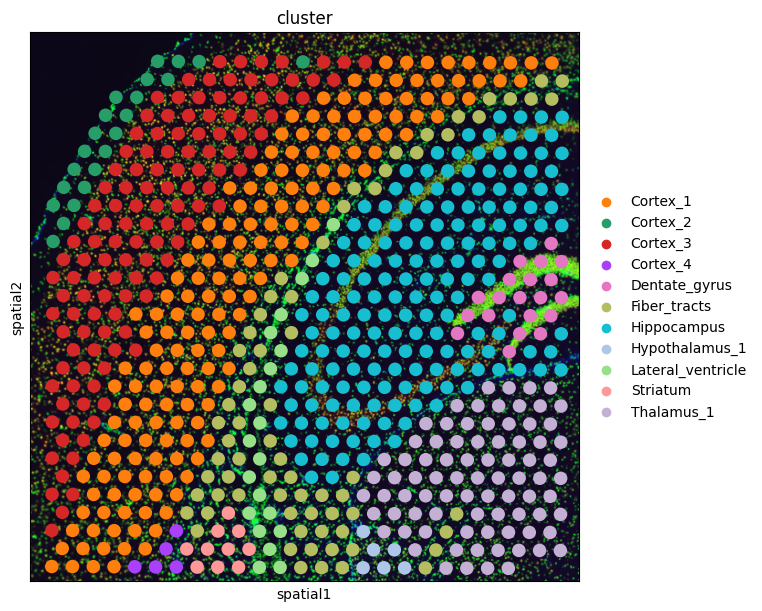

In [4]:
plt.rcParams['figure.figsize'] = (10,6)
# plt.rcParams['figure.dpi'] = 240

sq.pl.spatial_scatter(adata, color="cluster")


### The fluorescence image provided with this dataset has three channels

1. DAPI (specific to DNA)
2. anti-NEUN (specific to neurons)
3. anti-GFAP (specific to Glial cells). 

We can directly visualize the channels with the method squidpy.im.ImageContainer.show().

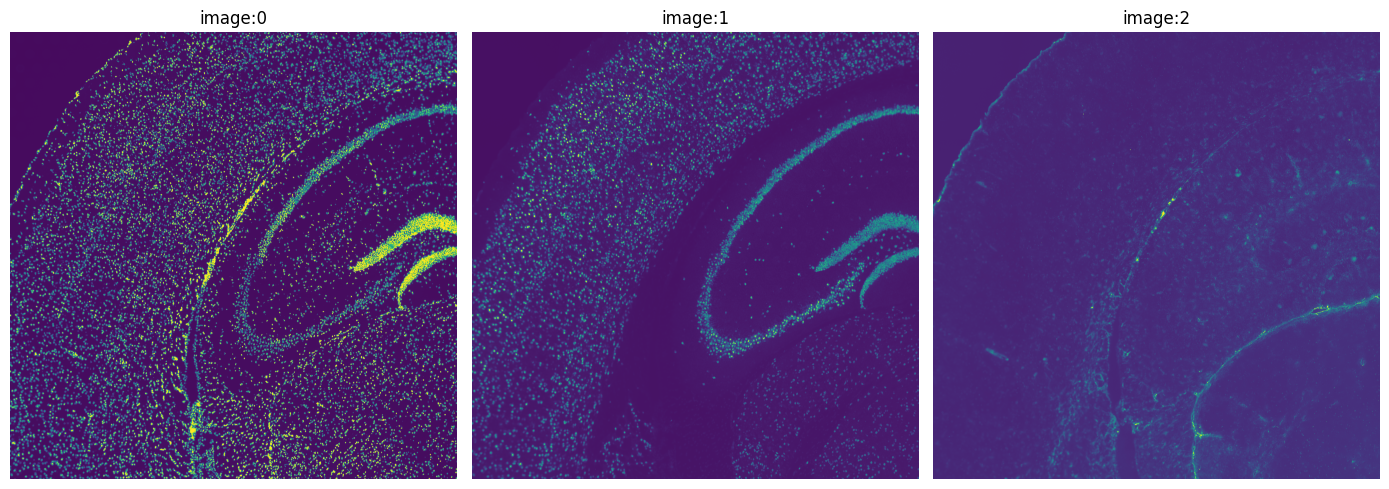

In [5]:
img.show(channelwise=True, figsize=(14,10))

In [6]:
img.__dict__

{'_data': <xarray.Dataset> Size: 317MB
 Dimensions:  (z: 1, y: 7272, x: 7272, channels: 3)
 Coordinates:
   * z        (z) <U38 152B 'V1_Adult_Mouse_Brain_Coronal_Section_2'
 Dimensions without coordinates: y, x, channels
 Data variables:
     image    (y, x, z, channels) uint16 317MB dask.array<chunksize=(7272, 7272, 1, 3), meta=np.ndarray>
 Attributes:
     coords:       CropCoords(x0=0, y0=0, x1=0, y1=0)
     padding:      CropPadding(x_pre=0, x_post=0, y_pre=0, y_post=0)
     scale:        1.0
     mask_circle:  False}

### Are there only 3 images? how to print each separately?

Not 3 images — it's one multi-channel image held in a single ImageContainer. The fluorescence image is a stack of marker channels (DAPI + antibody stains), and each "image" you might be seeing is actually one channel of that stack, not a separate layer.

First, inspect what's really there:

In [7]:
print(img)                      # shows layers + shape, e.g. ImageContainer[shape=(7272, 7272), layers=['image']]

ImageContainer[shape=(7272, 7272), layers=['image']]


In [8]:
print(img["image"].dims)        # ('y', 'x', 'z', 'channels')
print(img["image"].shape)       # last dim = number of channels
n_ch = img["image"].sizes["channels"]
print("channels:", n_ch)        # this fluo crop has 3

('y', 'x', 'z', 'channels')
(7272, 7272, 1, 3)
channels: 3


### One specific channel (antibody)

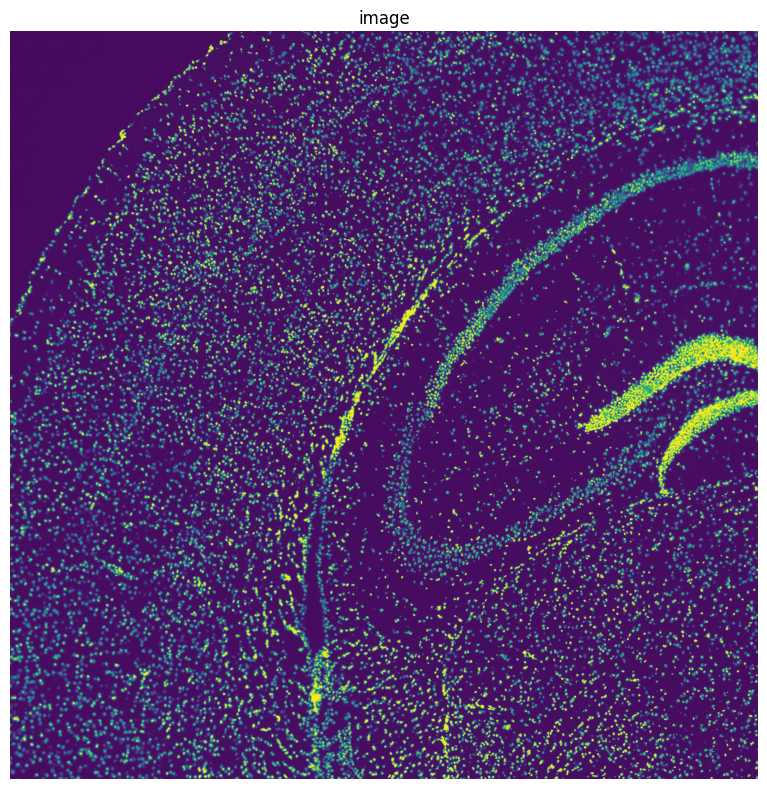

In [9]:
img.show(layer="image", channel=0, figsize=(8,8))   # DAPI

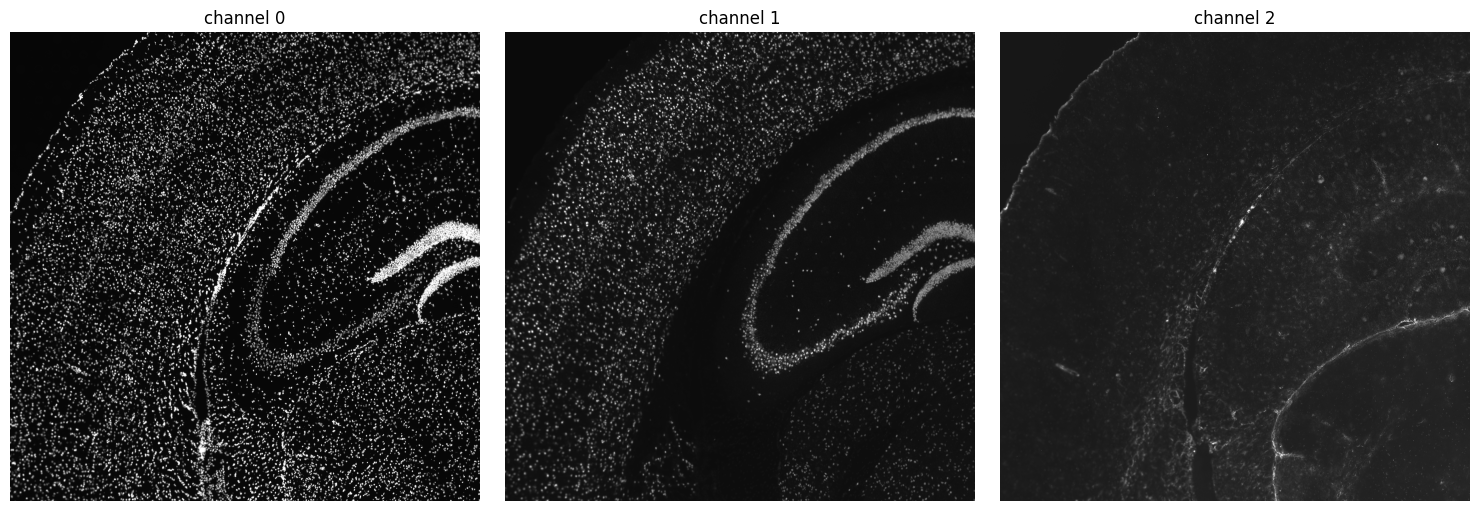

In [10]:
arr = img["image"]                       # dims (y, x, z, channels)
n_ch = img["image"].sizes["channels"]

fig, axes = plt.subplots(1, n_ch, figsize=(5 * n_ch, 5))

for c in range(n_ch):
    axes[c].imshow(arr.isel(z=0, channels=c), cmap="gray")
    axes[c].set_title(f"channel {c}")
    axes[c].axis("off")

plt.tight_layout()
plt.show()

### Expression

Given the DAPI image
Given the most highly expressed genes related to mitochondria
Get the first gene expression
Plot the overlap of the image cluster + expression dots 

In [11]:
print(adata)                    # overview: X, obs, var, obsm, uns
print(adata.shape)              # (704, 16562)  -> spots x genes

AnnData object with n_obs × n_vars = 704 × 16562
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT', 'log1p_total_counts_MT', 'pct_counts_MT', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'MT', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
    layers: None (.X)
(704, 16562)


In [12]:
adata.X[:5, :5].toarray() if hasattr(adata.X, "toarray") else adata.X[:5, :5]

array([[0.        , 0.        , 0.        , 0.        , 0.78493017],
       [0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 1.0222589 , 0.        ],
       [0.        , 0.        , 0.        , 1.3796557 , 0.        ]],
      dtype=float32)

In [13]:
X = adata.X
mx = X.max()
print("max value:", mx, "| looks like:", "counts" if float(mx).is_integer() else "normalized/log")
print("raw present:", adata.raw is not None)   # counts often stashed in adata.raw
print("layers:", list(adata.layers.keys()))

max value: 7.855473 | looks like: normalized/log
raw present: True
layers: [None]


In [14]:
adata.obs.columns          # includes 'cluster' -> the anatomical annotations

Index(['in_tissue', 'array_row', 'array_col', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'total_counts_MT', 'log1p_total_counts_MT', 'pct_counts_MT', 'n_counts',
       'leiden', 'cluster'],
      dtype='str')

In [15]:
adata.obsm['spatial']      # spot xy coordinates (align to the image)

array([[6744, 5901],
       [4422, 3264],
       [5393,  641],
       ...,
       [1678, 2775],
       [4696, 3265],
       [6474, 4944]], shape=(704, 2))

In [16]:
adata.uns['spatial']       # library id, image scalefactors, hires/lowres thumbnails

{'V1_Adult_Mouse_Brain_Coronal_Section_2': {'images': {'hires': array([[[0.04313726, 0.02745098, 0.09411765],
           [0.04313726, 0.02745098, 0.09411765],
           [0.04313726, 0.02745098, 0.09411765],
           ...,
           [0.22745098, 0.2784314 , 0.11764706],
           [0.2       , 0.2901961 , 0.11372549],
           [0.11372549, 0.14901961, 0.11372549]],
   
          [[0.04313726, 0.02745098, 0.09411765],
           [0.04313726, 0.02745098, 0.09411765],
           [0.04313726, 0.02745098, 0.09411765],
           ...,
           [0.16078432, 0.14117648, 0.11372549],
           [0.19607843, 0.18431373, 0.10980392],
           [0.14901961, 0.15686275, 0.10980392]],
   
          [[0.04313726, 0.02745098, 0.09411765],
           [0.04313726, 0.02745098, 0.09411765],
           [0.04313726, 0.02745098, 0.09411765],
           ...,
           [0.19607843, 0.19215687, 0.10980392],
           [0.34117648, 0.36862746, 0.10588235],
           [0.2784314 , 0.3137255 , 0.10980392]]

In [17]:
dfc = adata.var           # gene metadata
dfc.columns

Index(['gene_ids', 'feature_types', 'genome', 'MT', 'n_cells_by_counts',
       'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts',
       'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable',
       'highly_variable_rank', 'means', 'variances', 'variances_norm'],
      dtype='str')

In [18]:
dfc.head(3).T

,Xkr4,Gm19938,Sox17
gene_ids,ENSMUSG00000051951,ENSMUSG00000102331,ENSMUSG00000025902
feature_types,Gene Expression,Gene Expression,Gene Expression
genome,mm10,mm10,mm10
MT,False,False,False
n_cells_by_counts,103,173,205
mean_counts,0.038831,0.071607,0.080513
log1p_mean_counts,0.038097,0.069159,0.077436
pct_dropout_by_counts,96.330602,93.836836,92.696829
total_counts,109.0,201.0,226.0
log1p_total_counts,4.70048,5.308268,5.42495


### Mitochondrial gene expression

In [19]:
# 1. DAPI = channel 0 of the fluorescence stack (2D array, y-by-x)
dapi = img["image"].isel(z=0, channels=0).values

In [20]:
# 2. Mitochondrial genes, ranked by mean expression across spots
is_mito = adata.var_names.str.lower().str.startswith("mt-")
mito = adata.var_names[is_mito]
print("mito genes:", list(mito))

mito genes: ['mt-Nd1', 'mt-Nd2', 'mt-Co1', 'mt-Co2', 'mt-Atp8', 'mt-Atp6', 'mt-Co3', 'mt-Nd3', 'mt-Nd4l', 'mt-Nd4', 'mt-Nd5', 'mt-Nd6', 'mt-Cytb']


In [21]:
Xm = adata[:, mito].X
Xm = Xm.toarray() if hasattr(Xm, "toarray") else np.asarray(Xm)
mean_expr = pd.Series(Xm.mean(axis=0), index=mito).sort_values(ascending=False)
print(mean_expr)

mt-Co1     5.362803
mt-Co3     5.301704
mt-Atp6    5.249315
mt-Co2     4.876201
mt-Cytb    4.537133
mt-Nd4     4.419865
mt-Nd2     4.276057
mt-Nd1     4.217293
mt-Nd3     3.147671
mt-Nd5     2.639523
mt-Atp8    1.487151
mt-Nd4l    1.336349
mt-Nd6     0.209586
dtype: float32


In [22]:
# 3. First (most highly expressed) mito gene -> its per-spot vector
top_gene = mean_expr.index[0]
expr = adata[:, top_gene].X
expr = expr.toarray().ravel() if hasattr(expr, "toarray") else np.asarray(expr).ravel()

### Overlay: DAPI image + expression dots at spot coordinates

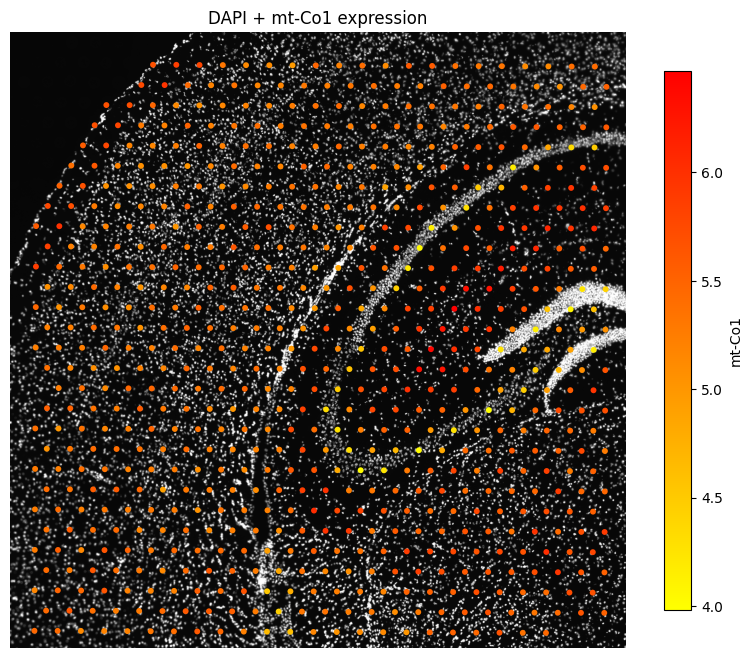

In [23]:
xy = adata.obsm["spatial"]              # pixel coords aligned to the full-res crop
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(dapi, cmap="gray")
pts = ax.scatter(xy[:, 0], xy[:, 1], c=expr, cmap="autumn_r", s=18, linewidths=0)
# pts = ax.scatter(xy[:, 0], xy[:, 1], c=expr, cmap="YlOrRd", s=18, linewidths=0)
# pts = ax.scatter(xy[:, 0], xy[:, 1], c=expr, cmap="viridis", s=18, linewidths=0)
plt.colorbar(pts, ax=ax, shrink=0.7, label=f"{top_gene}")
ax.set_title(f"DAPI + {top_gene} expression")
ax.axis("off")
plt.tight_layout()
plt.show()